
**Student ID:** `24018029`  
**GitHub Repo:** `https://github.com/OguzhanCel/YZM-2011-Project`


# 1. Problem Statement
The goal of this project is to compute peoples hemoglobin values from their face videos(1-2minutes) without video proccessing techniques to decrease the computation cost. if we manage to get good results we can use this in medical places to estimate peoples hemoglobin values.

**Why it matters & who benefits:**
- Rural/low-resource clinics without laboratory infrastructure can do anemia screening
- Pregnant women and children (anemia risk groups) can be monitored via phone
- Blood donation pre-screening without needles
- Home monitoring for elderly / chronic patients

**Prediction target:** Blood hemoglobin concentration (g/dL).

**Task type: Regression** 

# 2. Dataset Description
The data set is collected manually.
The original data set has 363 videos of humans standing in front of the camera but in the extraction part of this code the dataset we are going to make calculations will be created using mediapipe library what we are going to extract from the video is like this :
There will be 6 patches (25px points) that are chosen from user in this case the chosen patches are  like this:
 * P1: cene_sol       (172) The numeric code assigned to each facial landmark is used for tracking.
 * P2: sol_yanak_ic3  (136) 
 * P3: sag_yanak_ic3  (365) 
 * P4: alin_ust_orta   (21) 
 * P5: dudak_ustu       (0) 
 * P6: cene_sag       (397) 

from each of these points we are going to get the values for the according features:
 * R: the average intensity of the RED channel in that patch
 * G: the average intensity of the GREEN channel in that patch
 * B: the average intensity of the BLUE channel in that patch
 * Cr: This is a component from the YCbCr color space representing "Red-difference." It helps isolate color information from brightness.
 * C: A custom linear combination often used in rPPG algorithms to eliminate motion artifacts and highlight the pulse signal.

and these feature values are going to be saved for each frame until the video ends for every person in the dataset. In the end we are going to see a matrix for each person having a 30xN shape (N is the number of frames in the video). The final 30×N matrix represents a multivariate time series, where each of the 30 rows tracks a specific feature's change across N frames.

**Labels:** Hemoglobin values are stored in `info.xlsx`, column `Deger`. The 1st value corresponds to the 1st video (alphabetical order), and so on.

**Known limitations / biases:**
- Motion artifacts (subjects may move during 1-2 min recording)
- Narrow hemoglobin range in the dataset (most samples clustered in 10–14 g/dL)
- Lighting and skin-tone variability not controlled
- Small sample size relative to deep-learning needs

In [1]:
import cv2
import numpy as np
import os, sys, warnings
from pathlib import Path
from mediapipe import Image, ImageFormat
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
from scipy.stats.mstats import winsorize
import random



warnings.filterwarnings("ignore")

## Extraction from videos

#### Settings

In [2]:
# ──────────────────────────────────────────────────────────────
VIDEO_DIR   = "videos"
OUT_DIR     = "data"
PATCH_SIZE  = 25
MIN_DETECT  = 0.5
MIN_TRACK   = 0.5
SKIP_NO_FACE = True
VIDEO_EXTS  = {".mp4", ".avi", ".mov", ".mkv", ".wmv", ".flv", ".webm"}

LANDMARKS = {
    "N1_cene_sol":       172,
    "N2_sol_yanak_ic3":  136,
    "N3_sag_yanak_ic3":  365,
    "N4_alin_ust_orta":   21,
    "N5_dudak_ustu":       0,
    "N6_cene_sag":       397,
}
# ──────────────────────────────────────────────────────────────


#### Helper Functions For Extraction

In [3]:
def download_model():
    p = "face_landmarker.task"
    if not os.path.exists(p):
        print("  Model indiriliyor...")
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/mediapipe-models/"
            "face_landmarker/face_landmarker/float16/1/face_landmarker.task", p)
    return p


def patch_mean_rgb(frame_bgr, cx, cy, patch):
    h, w = frame_bgr.shape[:2]
    x1 = max(cx - patch, 0); x2 = min(cx + patch + 1, w)
    y1 = max(cy - patch, 0); y2 = min(cy + patch + 1, h)
    roi = frame_bgr[y1:y2, x1:x2]
    if roi.size == 0:
        return 0.0, 0.0, 0.0
    return float(roi[:,:,2].mean()), float(roi[:,:,1].mean()), float(roi[:,:,0].mean())


def compute_5(r, g, b):
    cr = 128.0 + 0.5*r - 0.4187*g - 0.0813*b
    c  = 3.0*r - 2.0*g
    return [r, g, b, cr, c]


def process_video(video_path, patch_size, model_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Acilamadi: {video_path}")
    ret, tf = cap.read()
    if not ret or tf is None:
        cap.release()
        raise IOError(f"Okunamadi: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=model_path),
        num_faces=1, min_face_detection_confidence=MIN_DETECT,
        min_face_presence_confidence=MIN_DETECT,
        min_tracking_confidence=MIN_TRACK,
        running_mode=mp_vision.RunningMode.VIDEO)
    det = mp_vision.FaceLandmarker.create_from_options(opts)

    lm_indices = list(LANDMARKS.values())
    columns, no_face, prev_row, fidx = [], 0, None, 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = det.detect_for_video(
            Image(image_format=ImageFormat.SRGB, data=np.array(rgb)),
            int(fidx*1000/fps))

        if res.face_landmarks:
            face = res.face_landmarks[0]
            row = []
            for lm_idx in lm_indices:
                lm = face[lm_idx]
                r, g, b = patch_mean_rgb(frame, int(lm.x*w), int(lm.y*h), patch_size)
                row.extend(compute_5(r, g, b))
            prev_row = row
            columns.append(row)
        else:
            no_face += 1
            if not SKIP_NO_FACE and prev_row is not None:
                columns.append(prev_row)
        fidx += 1

    cap.release(); det.close()
    if not columns:
        raise ValueError("Frame yok")

    matrix = np.array(columns, dtype=np.float32).T  
    return {"matrix": matrix, "n_frames": matrix.shape[1], "no_face": no_face}

### Extraction 

In [ ]:

model_path = download_model()
videos = sorted(p for p in Path(VIDEO_DIR).iterdir()
                if p.suffix.lower() in VIDEO_EXTS)
if not videos:
    print(f"HATA: {VIDEO_DIR}/ bos!")
    sys.exit()

os.makedirs(OUT_DIR, exist_ok=True)
print(f"\n{'='*60}")
print(f"  N1: cene_sol(172)  N2: sol_yanak_ic3(136)  N3: sag_yanak_ic3(365)")
print(f"  N4: alin_ust_orta(21)  N5: dudak_ustu(0)  N6: cene_sag(397)")
print(f"  {len(videos)} video → {OUT_DIR}/")
print(f"{'='*60}\n")

n_ok, n_skip, n_err = 0, 0, 0
for vidx, vpath in enumerate(videos):
    vname = vpath.stem
    out = Path(OUT_DIR) / f"{vname}.npy"
    if out.exists():
        n_skip += 1; continue
    try:
        res = process_video(vpath, PATCH_SIZE, model_path)
        nf_pct = 100*res["no_face"]/max(res["n_frames"]+res["no_face"],1)
        if res["n_frames"] < 300:
            n_err += 1; continue
        if nf_pct > 30:
            n_err += 1; continue
        np.save(str(out), res["matrix"])
        print(f"  [{vidx+1}/{len(videos)}]  {vname}  {res['matrix'].shape}  OK")
        n_ok += 1
    except Exception as e:
        print(f"  [{vidx+1}/{len(videos)}]  {vname}  Error: {e}")
        n_err += 1

print(f"\n  Successfull: {n_ok}  Skipped: {n_skip}  Error: {n_err}")

## Analysis of Data

### Loading a Single Video for Signal Analysis

The extraction above saves a `30×N` time-series matrix per video. For signal-level EDA, we load **one randomly selected `.npy` file** and convert it into a DataFrame where each row is a single frame and each column is one of the 30 raw channels.

The corresponding hemoglobin value is read from `info.xlsx`, column `Deger`, matched by positional order (1st video ↔ 1st value, and so on).

The aggregated dataset covering all videos (mean/std per channel + hemoglobin) is built later in Section 6 for multi-video correlation analysis.

In [4]:

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

# --- Config for EDA ---
EXCEL_PATH = "info.xlsx"
HB_COLUMN  = "Deger"
DATA_DIR   = OUT_DIR          
TABULAR_CSV = "features_tabular.csv"

CHANNELS = ["R", "G", "B", "Cr", "C"]
POINT_NAMES = list(LANDMARKS.keys())  

# Row order in 30×N matrix: N1_R, N1_G, N1_B, N1_Cr, N1_C, N2_R, ..., N6_C
ROW_LABELS = [f"{pt}_{ch}" for pt in POINT_NAMES for ch in CHANNELS]
assert len(ROW_LABELS) == 30
print(f"30 time series per video. Example row labels: {ROW_LABELS[:3]} ... {ROW_LABELS[-2:]}")

30 time series per video. Example row labels: ['N1_cene_sol_R', 'N1_cene_sol_G', 'N1_cene_sol_B'] ... ['N6_cene_sag_Cr', 'N6_cene_sag_C']


In [5]:

npy_files = sorted(Path(DATA_DIR).glob("*.npy"))
print(f"Found {len(npy_files)} .npy files in {DATA_DIR}/")

labels_xl = pd.read_excel(EXCEL_PATH)
print(f"Excel shape: {labels_xl.shape}")
hb_values = labels_xl[HB_COLUMN].values

#random.seed(42)   
idx = random.randint(0, len(npy_files) - 1)
chosen_npy = npy_files[idx]
hb_value = hb_values[idx]

print(f"\n✓ Selected video #{idx}: {chosen_npy.stem}")
print(f"  Hemoglobin: {hb_value} g/dL")

matrix = np.load(chosen_npy)    
print(f"  Matrix shape: {matrix.shape}  (30 channels × {matrix.shape[1]} frames)")

df = pd.DataFrame(matrix.T, columns=ROW_LABELS)
df.insert(0, "frame_idx", np.arange(len(df)))

print(f"\n✓ DataFrame built: {df.shape}")
print(f"  Columns: frame_idx + 30 channels (N1_R..N6_C)")

Found 361 .npy files in data/
Excel shape: (363, 2)

✓ Selected video #166: hem167
  Hemoglobin: 11.2 g/dL
  Matrix shape: (30, 2175)  (30 channels × 2175 frames)

✓ DataFrame built: (2175, 31)
  Columns: frame_idx + 30 channels (N1_R..N6_C)


## 3. Data Loading & Initial Inspection

In [6]:
print(f"Shape: {df.shape}")
print(f"Rows (videos): {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (2175, 31)
Rows (videos): 2175, Columns: 31


In [7]:
df.head()

,frame_idx,N1_cene_sol_R,N1_cene_sol_G,N1_cene_sol_B,N1_cene_sol_Cr,N1_cene_sol_C,N2_sol_yanak_ic3_R,N2_sol_yanak_ic3_G,N2_sol_yanak_ic3_B,N2_sol_yanak_ic3_Cr,N2_sol_yanak_ic3_C,N3_sag_yanak_ic3_R,N3_sag_yanak_ic3_G,N3_sag_yanak_ic3_B,N3_sag_yanak_ic3_Cr,N3_sag_yanak_ic3_C,N4_alin_ust_orta_R,N4_alin_ust_orta_G,N4_alin_ust_orta_B,N4_alin_ust_orta_Cr,N4_alin_ust_orta_C,N5_dudak_ustu_R,N5_dudak_ustu_G,N5_dudak_ustu_B,N5_dudak_ustu_Cr,N5_dudak_ustu_C,N6_cene_sag_R,N6_cene_sag_G,N6_cene_sag_B,N6_cene_sag_Cr,N6_cene_sag_C
0,0,79.959633,47.338333,32.804306,145.492264,145.202225,74.279510,44.569782,30.011150,144.038483,133.698959,144.006927,103.690117,91.655518,149.136810,224.640518,72.372162,49.298347,39.278355,140.351532,118.519798,119.495964,60.087273,41.841213,159.187744,238.313339,149.066895,112.344482,101.605537,147.234283,222.511719
1,1,80.159172,47.738945,32.527874,145.446777,144.999619,73.842369,45.542099,30.963860,143.335342,130.442902,141.445602,101.405228,88.407539,149.076904,221.526337,74.156097,51.681660,42.032681,140.021683,119.104958,119.681274,60.189926,41.571705,159.259338,238.663971,149.537094,113.130722,101.682426,147.133942,222.349869
2,2,80.615913,48.093040,33.367165,145.458649,145.661667,74.208763,45.608997,31.546713,143.443146,131.408310,141.988083,102.209534,89.612839,148.913391,221.545181,75.861206,53.599770,44.137638,139.899994,120.384087,120.074585,60.577469,42.447521,159.222519,239.068817,150.955399,114.444443,103.578239,147.138901,223.977310
3,3,80.183777,48.087273,33.693195,145.218491,144.376785,74.292198,45.740486,32.026527,143.390793,131.395615,143.745483,103.913879,92.193001,148.868713,223.408691,76.046524,53.873508,44.946945,139.812241,120.392540,119.373703,60.113033,42.276047,159.080475,237.895035,153.012299,115.648209,105.380623,147.516800,227.740479
4,4,80.251060,48.427528,34.345634,145.056625,143.898117,74.010765,45.971935,32.575932,143.108505,130.088425,145.928482,105.833908,94.851593,148.940155,226.117645,77.621681,54.691658,45.663589,140.198990,123.481735,119.736252,60.262978,42.395618,159.189255,238.682816,155.028839,117.592079,107.863899,147.509277,229.902344


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2175 entries, 0 to 2174
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   frame_idx            2175 non-null   int64  
 1   N1_cene_sol_R        2175 non-null   float32
 2   N1_cene_sol_G        2175 non-null   float32
 3   N1_cene_sol_B        2175 non-null   float32
 4   N1_cene_sol_Cr       2175 non-null   float32
 5   N1_cene_sol_C        2175 non-null   float32
 6   N2_sol_yanak_ic3_R   2175 non-null   float32
 7   N2_sol_yanak_ic3_G   2175 non-null   float32
 8   N2_sol_yanak_ic3_B   2175 non-null   float32
 9   N2_sol_yanak_ic3_Cr  2175 non-null   float32
 10  N2_sol_yanak_ic3_C   2175 non-null   float32
 11  N3_sag_yanak_ic3_R   2175 non-null   float32
 12  N3_sag_yanak_ic3_G   2175 non-null   float32
 13  N3_sag_yanak_ic3_B   2175 non-null   float32
 14  N3_sag_yanak_ic3_Cr  2175 non-null   float32
 15  N3_sag_yanak_ic3_C   2175 non-null   f

In [9]:
df.describe()

,frame_idx,N1_cene_sol_R,N1_cene_sol_G,N1_cene_sol_B,N1_cene_sol_Cr,N1_cene_sol_C,N2_sol_yanak_ic3_R,N2_sol_yanak_ic3_G,N2_sol_yanak_ic3_B,N2_sol_yanak_ic3_Cr,N2_sol_yanak_ic3_C,N3_sag_yanak_ic3_R,N3_sag_yanak_ic3_G,N3_sag_yanak_ic3_B,N3_sag_yanak_ic3_Cr,N3_sag_yanak_ic3_C,N4_alin_ust_orta_R,N4_alin_ust_orta_G,N4_alin_ust_orta_B,N4_alin_ust_orta_Cr,N4_alin_ust_orta_C,N5_dudak_ustu_R,N5_dudak_ustu_G,N5_dudak_ustu_B,N5_dudak_ustu_Cr,N5_dudak_ustu_C,N6_cene_sag_R,N6_cene_sag_G,N6_cene_sag_B,N6_cene_sag_Cr,N6_cene_sag_C
count,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000
mean,1087.000000,86.882538,51.444584,37.080624,146.886765,157.758423,81.338394,49.088264,35.203484,145.253891,145.838638,177.926453,136.403564,126.979828,149.527588,260.972229,84.734367,60.842556,53.464310,140.545761,132.518005,138.243347,74.496971,57.365414,161.265976,265.736115,186.386261,146.321548,138.034271,148.706116,266.515747
std,628.012739,3.295774,1.814548,1.835726,0.780556,6.376144,4.058527,2.243795,2.308467,0.938890,7.787766,15.370512,15.002534,15.867439,0.311754,16.169161,2.709252,2.271563,2.465706,0.418923,4.001058,10.638303,8.610810,8.776022,1.059485,14.790994,14.113336,13.563596,14.299894,0.376829,15.285913
min,0.000000,78.956169,47.219147,32.527874,144.789200,141.560944,72.345634,43.905422,29.783545,142.917542,127.712418,134.933487,94.903114,81.757401,148.540314,213.862366,72.372162,49.298347,39.278355,139.332565,118.499420,114.343330,55.856979,38.173779,158.394958,230.728180,145.189163,107.376396,96.171471,147.133942,219.326035
25%,543.500000,84.637638,50.051519,35.644176,146.427452,153.621300,77.989811,47.240484,33.316801,144.538567,139.659172,169.598419,128.035759,118.361015,149.324730,252.393120,82.968281,59.301807,51.866590,140.248726,130.076889,130.700890,68.037292,50.625721,160.600159,255.244133,179.957901,139.624954,130.879471,148.496620,259.776825
50%,1087.000000,87.718956,52.040752,37.563244,147.016678,159.093811,82.062286,49.555939,35.625145,145.384338,147.021530,184.137253,142.698578,133.537872,149.534622,266.918884,84.877357,61.101498,53.740868,140.571106,132.665131,140.963867,77.079971,59.981159,161.351181,268.614777,191.798920,151.658600,143.738556,148.725037,272.206451
75%,1630.500000,89.096310,52.824106,38.540945,147.412369,162.007500,84.819492,51.153212,37.271435,145.972839,152.157822,190.343712,148.440796,139.754326,149.727020,274.095734,86.895618,62.680508,55.361208,140.867828,135.716064,148.084000,82.457130,65.227604,162.167183,278.860443,196.893700,156.531143,148.941368,148.954132,278.054993
max,2174.000000,92.800461,54.396000,40.296425,148.640320,170.785858,88.053825,52.466358,39.309879,147.185242,160.495193,194.658203,152.382935,143.865814,150.503159,280.483673,90.471741,65.787392,58.961552,141.615723,141.293732,154.464828,86.698959,70.817375,163.373352,290.848145,202.233749,160.970016,154.033066,149.711563,285.188019


In [10]:
print("Dtype distribution:")
print(df.dtypes.value_counts())
print(f"\nNumerical columns: {df.select_dtypes(include=np.number).shape[1]}")
print(f"Object columns:    {df.select_dtypes(include='object').shape[1]}")

Dtype distribution:
float32    30
int64       1
Name: count, dtype: int64

Numerical columns: 31
Object columns:    0


## 4. Data Cleaning

### 4.1 Missing Values

In [11]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    "count": missing,
    "pct": (missing / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df["count"] > 0].sort_values("count", ascending=False)

print(f"Total missing values: {df.isnull().sum().sum()}")
if len(missing_df) > 0:
    print("\nColumns with missing values:")
    print(missing_df)
else:
    print("No missing values ✓")

Total missing values: 0
No missing values ✓


In [12]:
THRESHOLD = 0.05

if df.isnull().sum().sum() > 0:
    for col in df.columns:
        r = df[col].isnull().mean()
        if r == 0:
            continue
        if r < THRESHOLD and df[col].dtype in [np.float64, np.float32, np.int64]:
            df[col] = df[col].fillna(df[col].median())
            print(f"'{col}': filled with median ({r*100:.1f}% missing)")
        else:
            print(f"'{col}': {r*100:.1f}% missing — needs review")
    before = len(df)
    df = df.dropna()
    print(f"\n{before - len(df)} rows dropped. New shape: {df.shape}")
else:
    print("No cleaning needed.")

No cleaning needed.


### 4.2 Duplicate Rows

In [13]:
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates ✓")

Exact duplicate rows: 0
No duplicates ✓


### 4.3 Incorrect Dtypes

In [14]:
ID_COLS = ["frame_idx"]

object_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Object columns: {object_cols}")

for col in object_cols:
    if col in ID_COLS:
        continue
    try:
        df[col] = pd.to_numeric(df[col], errors="raise")
        print(f"'{col}' → numeric")
    except (ValueError, TypeError):
        print(f"'{col}' kept as object")

print(f"\nAll channel dtypes (should be float):")
print(df.dtypes.value_counts())

Object columns: []

All channel dtypes (should be float):
float32    30
int64       1
Name: count, dtype: int64


### 4.4 Outliers

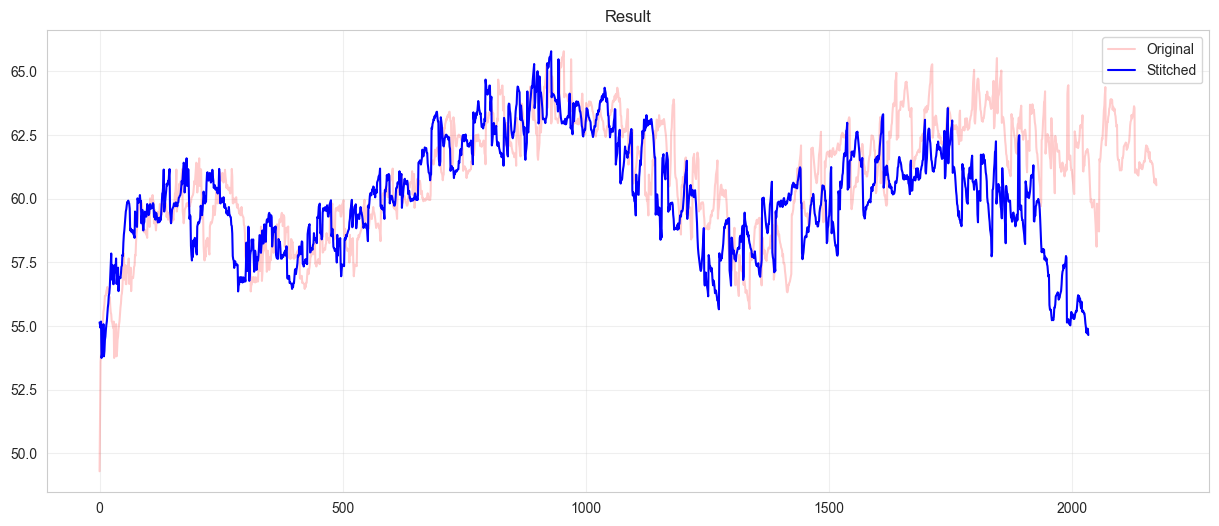

 New Dataset lenght: 2035


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation


def stitch_with_level_adjustment(df, mask, channels):

    df_clean = df[mask].copy()
    original_indices = df.index[mask].tolist()
    
    for col in channels:
        values = df_clean[col].values.astype(float)
        cumulative_offset = 0
        
        for i in range(1, len(original_indices)):
            if original_indices[i] > original_indices[i-1] + 1:
                val_before = df.loc[original_indices[i-1], col]
                val_after = df.loc[original_indices[i], col]
                
                step_diff = val_before - val_after
                cumulative_offset += step_diff
            
            values[i] += cumulative_offset
            
        df_clean[col] = values
        
    return df_clean.reset_index(drop=True)

def remove_noisy_segments(df, target_col, window_size=20, threshold_multiplier=2.5, dilation_size=10):

    signal = df[target_col].values
    
    rolling_std = pd.Series(signal).rolling(window=window_size, center=True).std()
    
    threshold = rolling_std.median() * threshold_multiplier
    
    bad_mask = rolling_std > threshold
    
    clean_mask = ~binary_dilation(bad_mask.fillna(False), iterations=dilation_size)
    
    df_filtered = df[clean_mask].reset_index(drop=True)
    
    return df_filtered, clean_mask

reference_channel = 'N4_alin_ust_orta_G'
_, final_mask = remove_noisy_segments(df, reference_channel, dilation_size=15)

channels_to_fix = [col for col in df.columns if col != 'frame_idx']
df_final = stitch_with_level_adjustment(df, final_mask, channels_to_fix)

plt.figure(figsize=(15, 6))
plt.plot(df[reference_channel], color='red', alpha=0.2, label='Original')
plt.plot(df_final[reference_channel], color='blue', linewidth=1.5, label='Stitched')

plt.title("Result")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f" New Dataset lenght: {len(df_final)}")

### 4.5 Inconsistent Categories

In [16]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c not in ID_COLS]
if cat_cols:
    for col in cat_cols:
        print(f"\n'{col}' value counts:")
        print(df[col].value_counts().head(10))
else:
    print("No categorical features (all features are numeric signal-processing outputs).")

print(f"\n✓ Cleaning done. Final shape: {df.shape}")

No categorical features (all features are numeric signal-processing outputs).

✓ Cleaning done. Final shape: (2175, 31)


## 5. Univariate Analysis

### 5.1 Target: Hemoglobin

In [17]:
all_hb = pd.Series(hb_values).dropna()
TARGET_NAME = "Hemoglobin"

print(f"=== {TARGET_NAME} Dataset Distribution ({len(all_hb)} samples) ===")
print(f"Mean:     {all_hb.mean():.2f} g/dL")
print(f"Median:   {all_hb.median():.2f} g/dL")
print(f"Std:      {all_hb.std():.2f} g/dL")
print(f"Min/Max:  {all_hb.min():.2f} / {all_hb.max():.2f} g/dL")
print(f"Range:    {all_hb.max()-all_hb.min():.2f} g/dL")
print(f"Skewness: {all_hb.skew():.3f}")
print(f"Kurtosis: {all_hb.kurtosis():.3f}")

print(f"\n=== Clinical Distribution ===")
print(f"Severe anemia   (<8):     {(all_hb<8).sum()} ({(all_hb<8).mean()*100:.1f}%)")
print(f"Moderate anemia (8–10):   {((all_hb>=8)&(all_hb<10)).sum()} ({((all_hb>=8)&(all_hb<10)).mean()*100:.1f}%)")
print(f"Mild anemia     (10–12):  {((all_hb>=10)&(all_hb<12)).sum()} ({((all_hb>=10)&(all_hb<12)).mean()*100:.1f}%)")
print(f"Normal          (12–16):  {((all_hb>=12)&(all_hb<16)).sum()} ({((all_hb>=12)&(all_hb<16)).mean()*100:.1f}%)")
print(f"High            (>16):    {(all_hb>=16).sum()} ({(all_hb>=16).mean()*100:.1f}%)")

print(f"\n=== Selected Video (for signal analysis) ===")
print(f"Video ID:    {chosen_npy.stem}")
print(f"Hemoglobin:  {hb_value} g/dL")

=== Hemoglobin Dataset Distribution (363 samples) ===
Mean:     12.24 g/dL
Median:   12.10 g/dL
Std:      1.43 g/dL
Min/Max:  8.90 / 15.80 g/dL
Range:    6.90 g/dL
Skewness: 0.254
Kurtosis: -0.663

=== Clinical Distribution ===
Severe anemia   (<8):     0 (0.0%)
Moderate anemia (8–10):   13 (3.6%)
Mild anemia     (10–12):  153 (42.1%)
Normal          (12–16):  197 (54.3%)
High            (>16):    0 (0.0%)

=== Selected Video (for signal analysis) ===
Video ID:    hem167
Hemoglobin:  11.2 g/dL


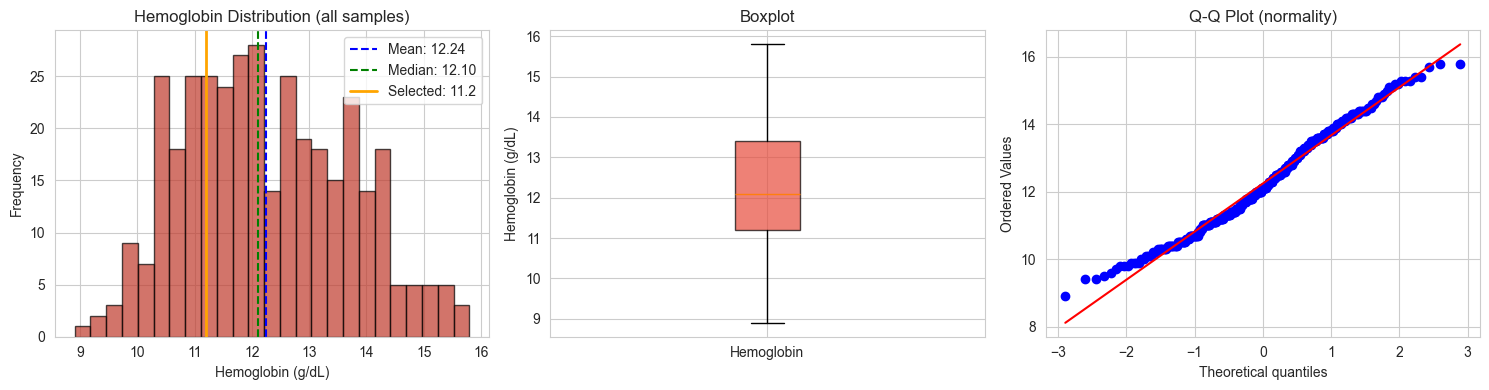

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(all_hb, bins=25, edgecolor="black", alpha=0.7, color="#c0392b")
axes[0].axvline(all_hb.mean(),   color="blue",  linestyle="--", label=f"Mean: {all_hb.mean():.2f}")
axes[0].axvline(all_hb.median(), color="green", linestyle="--", label=f"Median: {all_hb.median():.2f}")
axes[0].axvline(hb_value, color="orange", linestyle="-", linewidth=2, label=f"Selected: {hb_value}")
axes[0].set_xlabel("Hemoglobin (g/dL)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Hemoglobin Distribution (all samples)")
axes[0].legend()

axes[1].boxplot(all_hb, patch_artist=True, boxprops=dict(facecolor="#e74c3c", alpha=0.7))
axes[1].set_ylabel("Hemoglobin (g/dL)")
axes[1].set_title("Boxplot")
axes[1].set_xticklabels(["Hemoglobin"])

stats.probplot(all_hb, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (normality)")

plt.tight_layout()
plt.show()

### 5.2 Numerical Features

In [19]:
feature_cols = [c for c in df.columns if c != "frame_idx"]

fs = df[feature_cols].agg(["mean", "median", "std", "skew"]).T
fs.columns = ["mean", "median", "std", "skewness"]
fs = fs.round(4)
print(f"Total numerical features: {len(feature_cols)}\n")
print("First 15 features:")
fs.head(15)

Total numerical features: 30

First 15 features:


,mean,median,std,skewness
N1_cene_sol_R,86.882500,87.719002,3.295800,-0.5462
N1_cene_sol_G,51.444599,52.040798,1.814500,-0.5532
N1_cene_sol_B,37.080601,37.563202,1.835700,-0.5166
N1_cene_sol_Cr,146.886795,147.016693,0.780600,-0.4374
N1_cene_sol_C,157.758408,159.093796,6.376100,-0.5029
N2_sol_yanak_ic3_R,81.338402,82.062302,4.058500,-0.4199
N2_sol_yanak_ic3_G,49.088299,49.555901,2.243800,-0.4495
N2_sol_yanak_ic3_B,35.203499,35.625099,2.308500,-0.3571
N2_sol_yanak_ic3_Cr,145.253906,145.384293,0.938900,-0.3461
N2_sol_yanak_ic3_C,145.838593,147.021500,7.787800,-0.3823


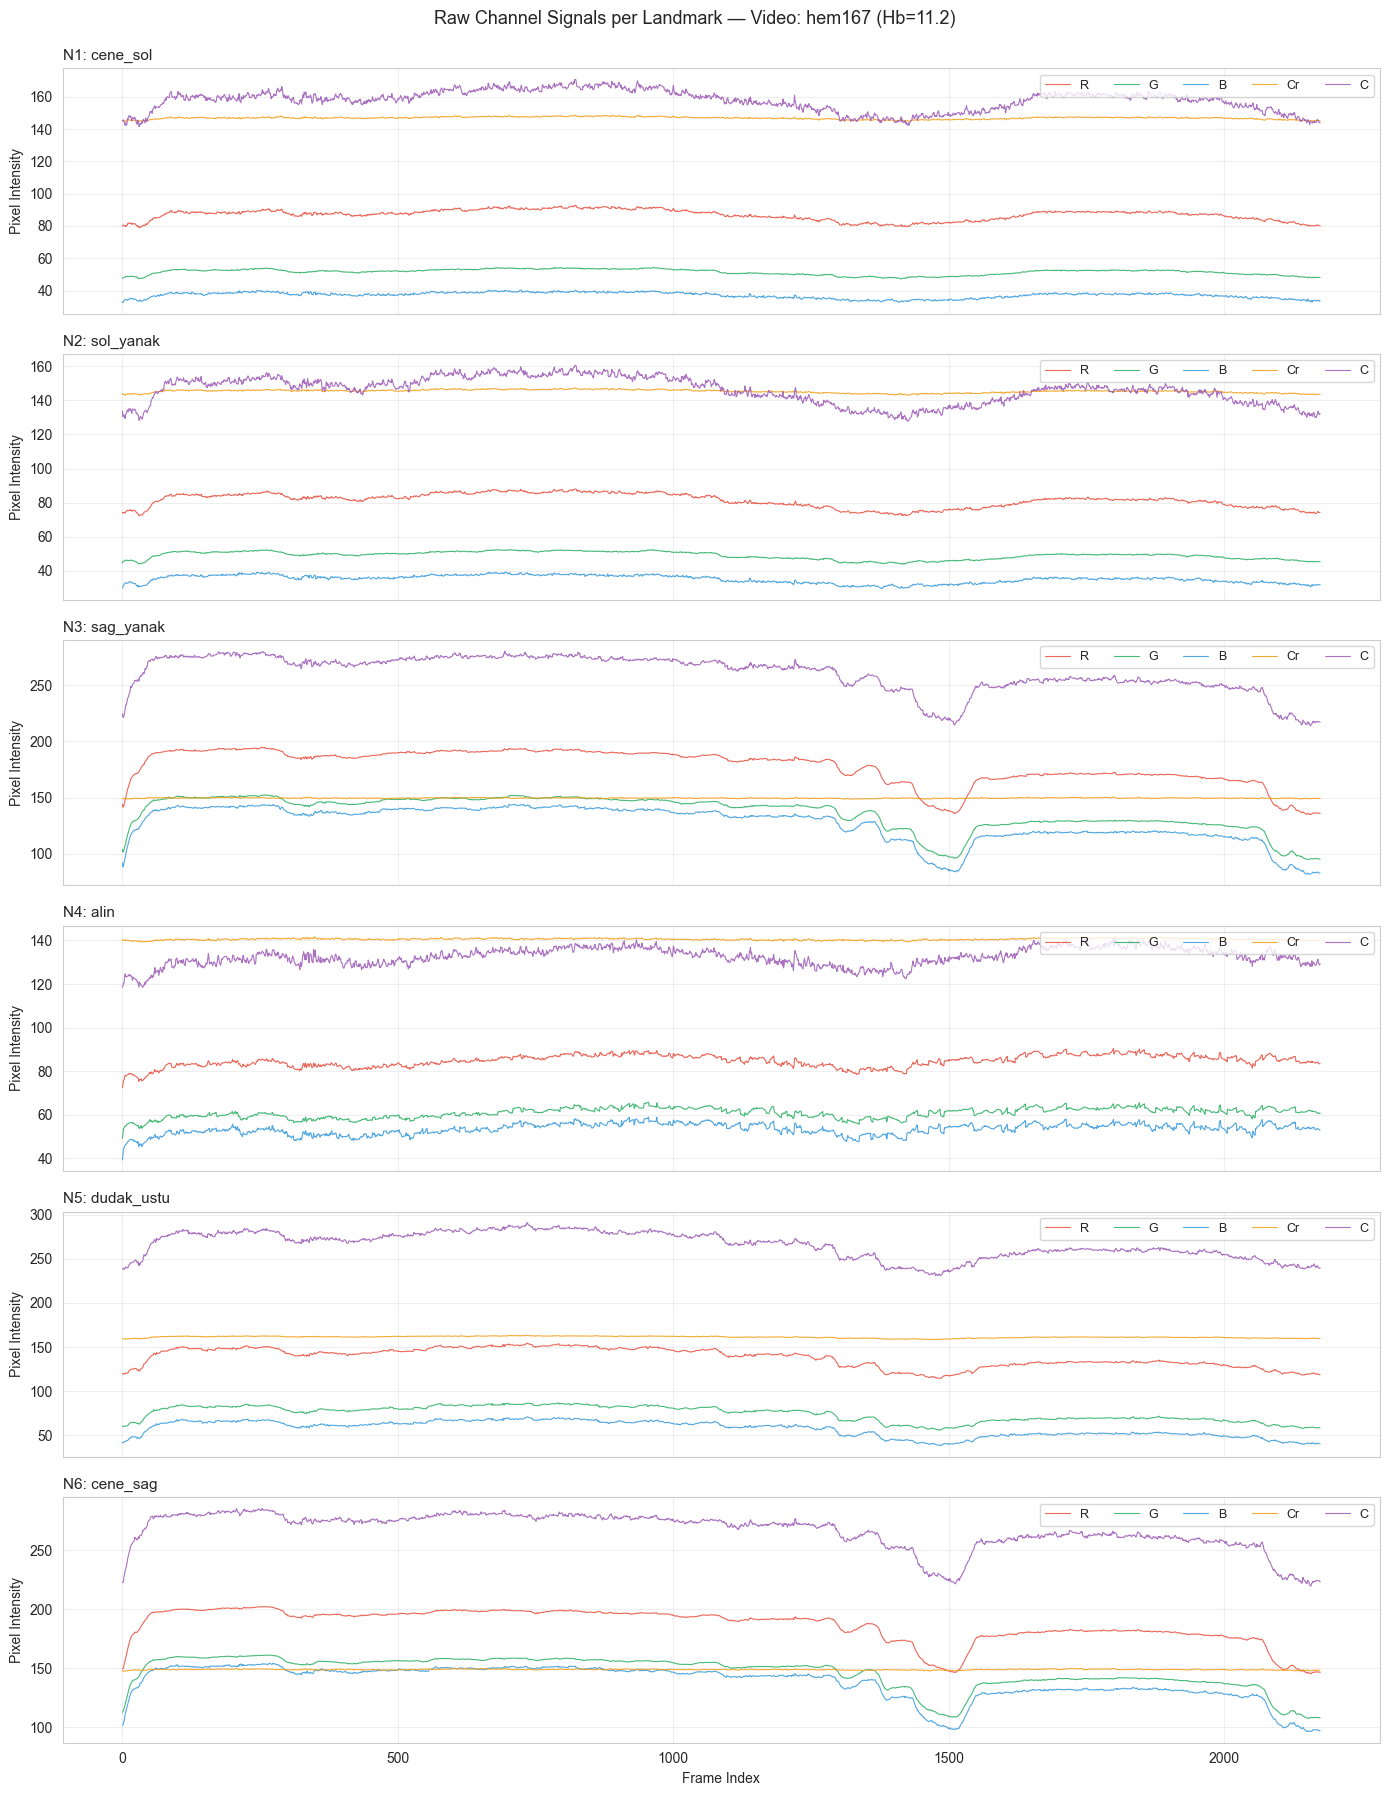

In [20]:
point_tags = ["N1", "N2", "N3", "N4", "N5", "N6"]
point_names = ["cene_sol", "sol_yanak", "sag_yanak", "alin", "dudak_ustu", "cene_sag"]
channel_colors = {"R": "#e74c3c", "G": "#27ae60", "B": "#3498db", 
                  "Cr": "#f39c12", "C": "#9b59b6"}

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

for i, (tag, name) in enumerate(zip(point_tags, point_names)):
    ax = axes[i]
    point_cols = [c for c in feature_cols if c.startswith(tag + "_")]
    
    for col in point_cols:
        ch = col.split("_")[-1]
        ax.plot(df["frame_idx"], df[col], 
                label=ch, color=channel_colors.get(ch, "gray"), 
                linewidth=0.8, alpha=0.85)
    
    ax.set_title(f"{tag}: {name}", fontsize=11, loc="left")
    ax.set_ylabel("Pixel Intensity")
    ax.legend(loc="upper right", ncol=5, fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Frame Index")
plt.suptitle(f"Raw Channel Signals per Landmark — Video: {chosen_npy.stem} (Hb={hb_value})", 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

### 5.3 Categorical Features

In [21]:
if cat_cols:
    for col in cat_cols:
        vc = df[col].value_counts().head(10)
        fig, ax = plt.subplots(figsize=(8, 4))
        vc.plot(kind="bar", ax=ax, color="#2ecc71", edgecolor="black")
        ax.set_title(f"Top categories: {col}")
        ax.set_ylabel("Frequency")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        print(f"'{col}':\n{vc}\n")
else:
    print("No categorical features in this dataset (all are signal-derived numeric).")

No categorical features in this dataset (all are signal-derived numeric).


## 6. Bivariate & Multivariate Analysis

In [22]:
agg_rows = []
for i, npf in enumerate(npy_files):
    if i >= len(hb_values):
        break
    hb = hb_values[i]
    if pd.isna(hb):
        continue
    matrix = np.load(npf)  # (30, N)
    row = {"video_id": npf.stem, "hemoglobin": float(hb)}
    for r_idx, label in enumerate(ROW_LABELS):
        row[label + "_mean"] = float(matrix[r_idx].mean())
        row[label + "_std"]  = float(matrix[r_idx].std())
    agg_rows.append(row)

agg_df = pd.DataFrame(agg_rows)
print(f"Aggregated dataset: {agg_df.shape}")
print(f"Videos: {len(agg_df)}, channels summarized: 30 × 2 (mean + std)")

Aggregated dataset: (361, 62)
Videos: 361, channels summarized: 30 × 2 (mean + std)


### 6.1 Target Correlations

In [23]:
channel_cols = [c for c in agg_df.columns if c not in ["video_id", "hemoglobin"]]
correlations = agg_df[channel_cols].corrwith(agg_df["hemoglobin"]).sort_values(key=abs, ascending=False)

print("=== Top 15 channels correlated with hemoglobin ===")
print(correlations.head(15).round(4))
print("\n=== Bottom 10 (lowest |r|) ===")
print(correlations.tail(10).round(4))

=== Top 15 channels correlated with hemoglobin ===
N1_cene_sol_B_mean          0.3996
N5_dudak_ustu_C_mean       -0.3733
N5_dudak_ustu_R_mean       -0.3703
N1_cene_sol_G_mean          0.3640
N1_cene_sol_Cr_mean        -0.3554
N5_dudak_ustu_Cr_mean      -0.3530
N2_sol_yanak_ic3_Cr_mean   -0.3386
N5_dudak_ustu_G_mean       -0.3372
N4_alin_ust_orta_B_mean     0.3260
N2_sol_yanak_ic3_B_mean     0.3129
N4_alin_ust_orta_G_mean     0.3104
N5_dudak_ustu_B_mean       -0.3044
N4_alin_ust_orta_R_mean     0.2641
N2_sol_yanak_ic3_G_mean     0.2605
N1_cene_sol_R_mean          0.2549
dtype: float64

=== Bottom 10 (lowest |r|) ===
N2_sol_yanak_ic3_R_std    -0.0420
N5_dudak_ustu_R_std       -0.0411
N3_sag_yanak_ic3_G_mean    0.0349
N4_alin_ust_orta_G_std    -0.0309
N1_cene_sol_G_std          0.0272
N3_sag_yanak_ic3_Cr_std   -0.0242
N3_sag_yanak_ic3_R_mean   -0.0233
N6_cene_sag_Cr_std        -0.0046
N4_alin_ust_orta_B_std    -0.0038
N6_cene_sag_C_mean         0.0038
dtype: float64


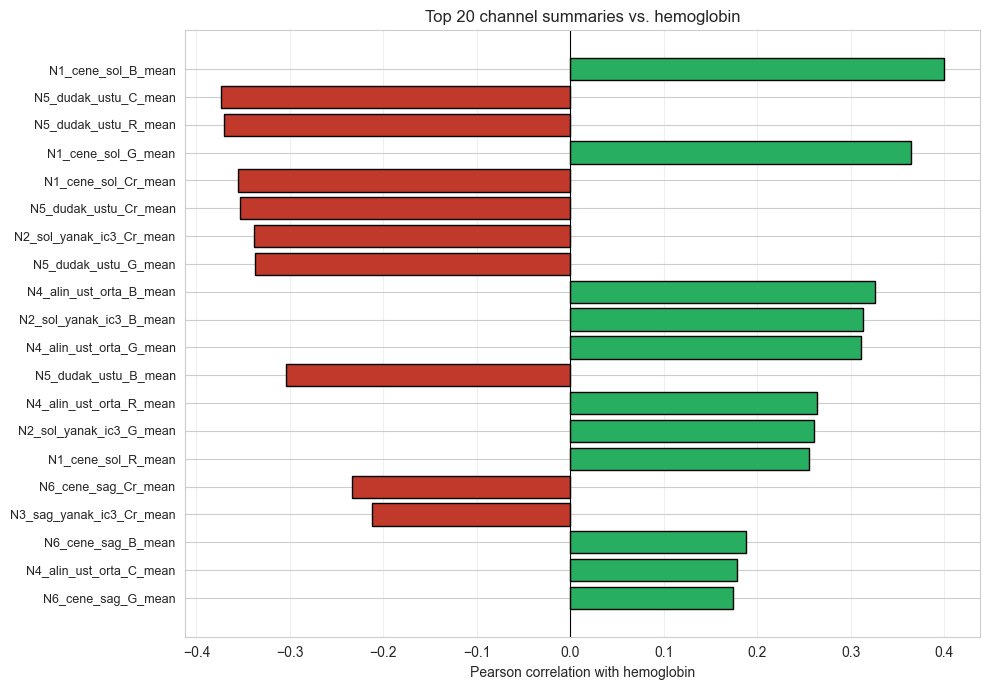

In [24]:
top_corr = correlations.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#27ae60" if v > 0 else "#c0392b" for v in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor="black")
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Pearson correlation with hemoglobin")
ax.set_title("Top 20 channel summaries vs. hemoglobin")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Correlation Heatmap

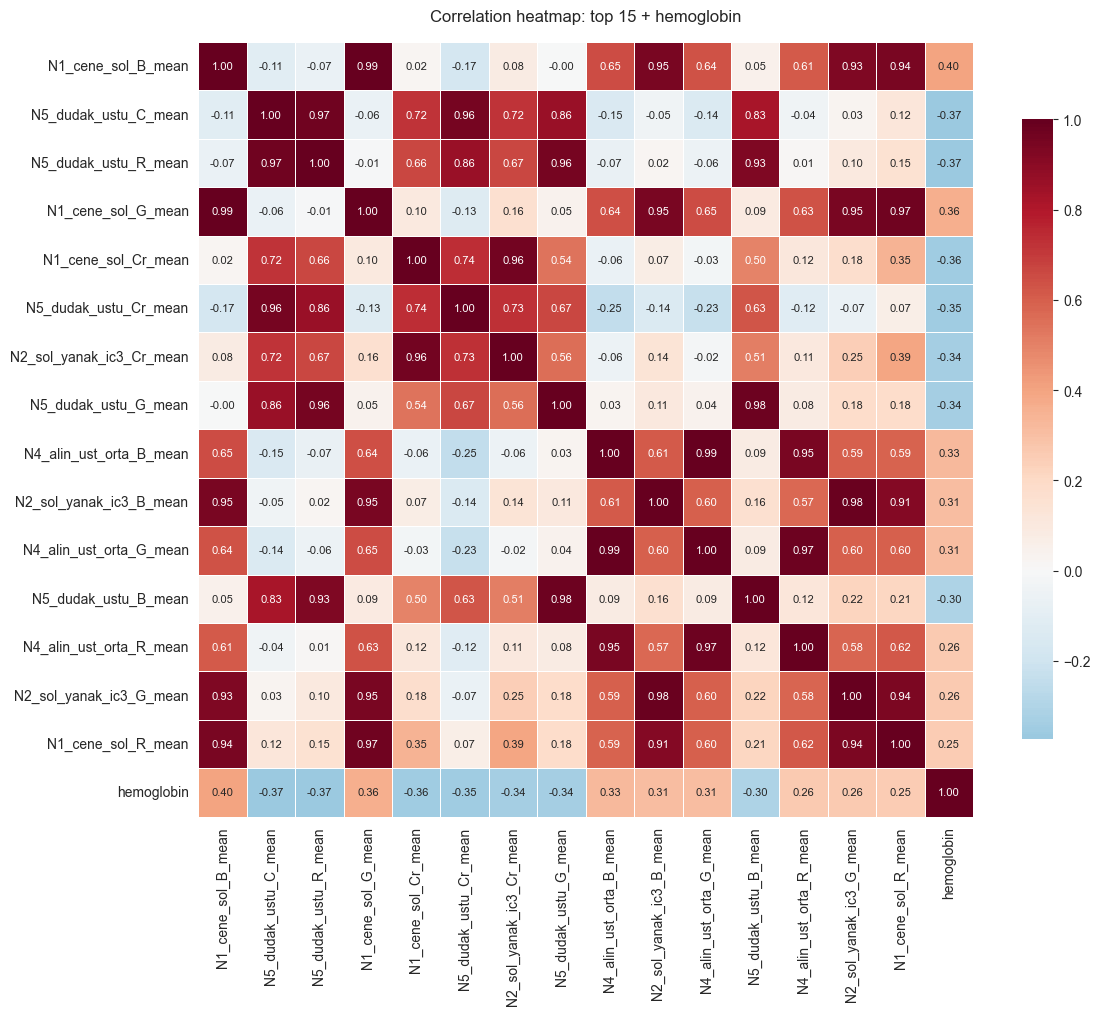

In [25]:
top_features = correlations.head(15).index.tolist()
corr_matrix = agg_df[top_features + ["hemoglobin"]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlation heatmap: top 15 + hemoglobin", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

### 6.3 Multicollinearity among top features

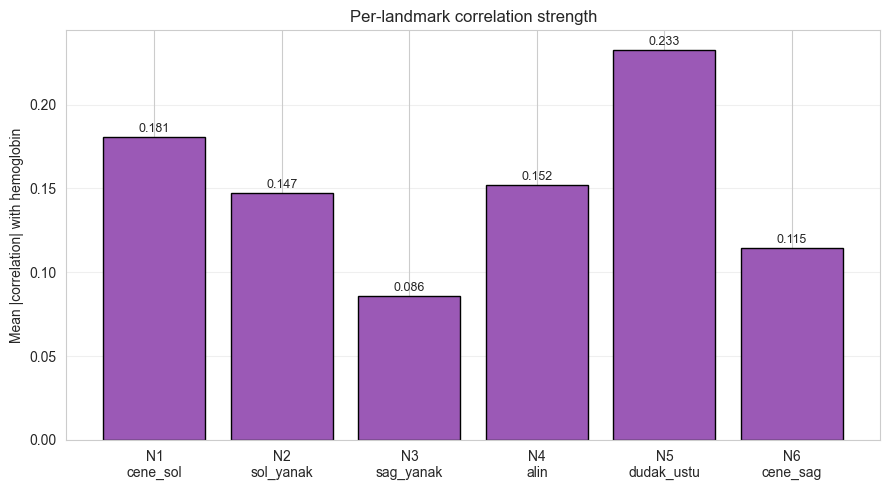

In [26]:
point_tags = ["N1", "N2", "N3", "N4", "N5", "N6"]
point_names = ["cene_sol", "sol_yanak", "sag_yanak", "alin", "dudak_ustu", "cene_sag"]

point_abs_corr = {}
for tag in point_tags:
    cols = [c for c in channel_cols if c.startswith(tag + "_")]
    if cols:
        point_abs_corr[tag] = correlations[cols].abs().mean()

fig, ax = plt.subplots(figsize=(9, 5))
tags = list(point_abs_corr.keys())
vals = list(point_abs_corr.values())
labels = [f"{t}\n{n}" for t, n in zip(tags, point_names)]
bars = ax.bar(labels, vals, color="#9b59b6", edgecolor="black")
ax.set_ylabel("Mean |correlation| with hemoglobin")
ax.set_title("Per-landmark correlation strength")
ax.grid(axis="y", alpha=0.3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Key Findings & Next Steps

### Key Findings 

**1. Narrow hemoglobin distribution limits achievable R²**  
Most hemoglobin samples cluster in 10–14 g/dL; extreme values (<8 or >16 g/dL) are rare or absent. This will cap the variance the model can learn.

**2. Data is clean; motion results remain the main noise source**  
No missing/duplicate issues after extraction. However, subject motion during recording (acknowledged in dataset description) causes noise that signal-level features alone cannot fully compensate for.

### Remaining Data Quality Issues
- Motion-induced noise (subjects don't stay still for 1–2 min)
- Dataset size relative to deep-learning needs